<a href="https://www.kaggle.com/code/ahmedfakhar123/ml-50-adaboost-intuition-implementation?scriptVersionId=351634632" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="background: linear-gradient(135deg, #1a0a00 0%, #2d1200 50%, #1a0800 100%); padding: 48px 40px; border-radius: 16px; margin-bottom: 8px; border: 1px solid #5c2800;">
  <div style="display: flex; align-items: center; gap: 12px; margin-bottom: 16px;">
    <span style="background: #f97316; color: #1a0a00; font-size: 11px; font-weight: 700; letter-spacing: 2px; padding: 4px 12px; border-radius: 20px; text-transform: uppercase;">ML Series · Episode 50</span>
    <span style="background: rgba(255,255,255,0.08); color: #fdba74; font-size: 11px; font-weight: 600; padding: 4px 12px; border-radius: 20px;">From Scratch + sklearn</span>
  </div>
  <h1 style="color: #ffffff; font-size: 38px; font-weight: 800; margin: 0 0 12px 0; line-height: 1.2;">🚀 AdaBoost</h1>
  <p style="color: #fb923c; font-size: 16px; margin: 0 0 6px 0; font-style: italic;">Adaptive Boosting — Intuition &amp; Implementation</p>
  <p style="color: #fed7aa; font-size: 15px; margin: 0 0 28px 0; max-width: 700px; line-height: 1.6;">The first and most elegant boosting algorithm — train weak learners sequentially, let each one focus on the mistakes of the previous ones, and combine them into a powerful ensemble. Built step-by-step from scratch before using sklearn.</p>
  <div style="display: flex; gap: 20px; flex-wrap: wrap;">
    <div style="background: rgba(255,255,255,0.06); border: 1px solid #5c2800; border-radius: 10px; padding: 14px 20px;">
      <div style="color: #f97316; font-size: 20px; font-weight: 700;">From Scratch</div>
      <div style="color: #fdba74; font-size: 12px; margin-top: 2px;">Build 3 stumps manually, step by step</div>
    </div>
    <div style="background: rgba(255,255,255,0.06); border: 1px solid #5c2800; border-radius: 10px; padding: 14px 20px;">
      <div style="color: #f97316; font-size: 20px; font-weight: 700;">Sample Weights</div>
      <div style="color: #fdba74; font-size: 12px; margin-top: 2px;">The core mechanism that makes boosting work</div>
    </div>
    <div style="background: rgba(255,255,255,0.06); border: 1px solid #5c2800; border-radius: 10px; padding: 14px 20px;">
      <div style="color: #f97316; font-size: 20px; font-weight: 700;">make_circles</div>
      <div style="color: #fdba74; font-size: 12px; margin-top: 2px;">Non-linear boundary — where single trees fail</div>
    </div>
  </div>
</div>

<div style="background: #100500; border-left: 5px solid #f97316; border-radius: 0 10px 10px 0; padding: 20px 24px; margin: 24px 0; border: 1px solid #5c2800; border-left: 5px solid #f97316;">
  <h2 style="color: #f97316; font-size: 15px; font-weight: 700; text-transform: uppercase; letter-spacing: 1.5px; margin: 0 0 10px 0;">📋 Table of Contents</h2>
  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 4px;">
    <ol style="margin: 0; padding-left: 20px; color: #fb923c; line-height: 2.1; font-size: 14px;">
      <li><a href='#what' style='color: #fb923c; text-decoration: none;'>What is AdaBoost?</a></li>
      <li><a href='#algorithm' style='color: #fb923c; text-decoration: none;'>The AdaBoost Algorithm</a></li>
      <li><a href='#imports' style='color: #fb923c; text-decoration: none;'>Imports</a></li>
      <li><a href='#dataset' style='color: #fb923c; text-decoration: none;'>Toy Dataset &amp; Uniform Weights</a></li>
      <li><a href='#stump1' style='color: #fb923c; text-decoration: none;'>Stump 1 — Train, Error &amp; Alpha</a></li>
      <li><a href='#update1' style='color: #fb923c; text-decoration: none;'>Update &amp; Normalise Sample Weights</a></li>
      <li><a href='#resample' style='color: #fb923c; text-decoration: none;'>Weighted Resampling — New Dataset</a></li>
    </ol>
    <ol start="8" style="margin: 0; padding-left: 20px; color: #fb923c; line-height: 2.1; font-size: 14px;">
      <li><a href='#stump2' style='color: #fb923c; text-decoration: none;'>Stump 2 — Repeat on Hard Samples</a></li>
      <li><a href='#stump3' style='color: #fb923c; text-decoration: none;'>Stump 3 — Final Weak Learner</a></li>
      <li><a href='#predict' style='color: #fb923c; text-decoration: none;'>Final Prediction — Weighted Vote</a></li>
      <li><a href='#vs' style='color: #fb923c; text-decoration: none;'>Bagging vs Boosting</a></li>
      <li><a href='#sklearn' style='color: #fb923c; text-decoration: none;'>AdaBoost with sklearn</a></li>
      <li><a href='#tuning' style='color: #fb923c; text-decoration: none;'>Hyperparameter Tuning</a></li>
    </ol>
  </div>
</div>

<a id='what'></a>
<div style="border-bottom: 2px solid #f97316; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #f97316; color: #1a0a00; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 1</span>
  <h2 style="color: #fed7aa; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">🚀 What is AdaBoost?</h2>
</div>

**AdaBoost (Adaptive Boosting)** was introduced by Freund &amp; Schapire in 1997 — one of the most influential papers in ML history, winning the Gödel Prize. It was the first practical boosting algorithm, showing that any collection of weak learners (models just slightly better than random guessing) can be combined into an arbitrarily strong learner.

<div style="background: #100500; border: 1px solid #5c2800; border-radius: 12px; padding: 24px 28px; margin: 20px 0;">
  <div style="color: #fdba74; font-size: 11px; letter-spacing: 1.5px; text-transform: uppercase; margin-bottom: 14px;">The Core Idea</div>
  <div style="display: flex; flex-direction: column; gap: 10px;">
    <div style="display: flex; gap: 12px; align-items: flex-start;">
      <span style="background: #f97316; color: #1a0a00; font-weight: 700; font-size: 12px; padding: 2px 10px; border-radius: 10px; white-space: nowrap; margin-top: 1px;">Round 1</span>
      <span style="color: #fed7aa; font-size: 13px;">Train a weak learner (depth-1 Decision Tree = "stump") on the data where <strong style='color:#fff;'>all samples have equal weight</strong>. Some samples are misclassified.</span>
    </div>
    <div style="display: flex; gap: 12px; align-items: flex-start;">
      <span style="background: #f97316; color: #1a0a00; font-weight: 700; font-size: 12px; padding: 2px 10px; border-radius: 10px; white-space: nowrap; margin-top: 1px;">Round 2</span>
      <span style="color: #fed7aa; font-size: 13px;"><strong style='color:#fff;'>Increase the weight of misclassified samples</strong>, decrease the weight of correctly classified ones. The next stump must pay more attention to the hard examples.</span>
    </div>
    <div style="display: flex; gap: 12px; align-items: flex-start;">
      <span style="background: #f97316; color: #1a0a00; font-weight: 700; font-size: 12px; padding: 2px 10px; border-radius: 10px; white-space: nowrap; margin-top: 1px;">Round N</span>
      <span style="color: #fed7aa; font-size: 13px;">Repeat — each round focuses on what all previous rounds got wrong. Combine all stumps via <strong style='color:#fff;'>weighted majority vote</strong> where better stumps get higher votes.</span>
    </div>
  </div>
  <div style="margin-top: 16px; padding-top: 12px; border-top: 1px solid #5c2800; color: #fdba74; font-size: 13px; text-align: center; font-family: Georgia, serif;">
    Final prediction: &nbsp;<strong style='color:#f97316;'>ŷ = sign( Σ αₜ · hₜ(x) )</strong>&nbsp; — weighted sum of all stumps' predictions
  </div>
</div>

<div style="display: grid; grid-template-columns: 1fr 1fr; gap: 14px; margin: 16px 0;">
  <div style="background: #100500; border: 1px solid #5c2800; border-top: 2px solid #22c55e; border-radius: 0 0 8px 8px; padding: 14px 16px;">
    <div style="color: #22c55e; font-weight: 700; font-size: 13px; margin-bottom: 6px;">✅ What AdaBoost fixes</div>
    <div style="color: #fed7aa; font-size: 13px; line-height: 1.7;">A single Decision Stump (depth=1) has high bias — it's barely better than random. AdaBoost <strong style='color:#fff;'>reduces bias</strong> by sequentially stacking stumps, each correcting residual errors. 100 stumps beat any single deep tree.</div>
  </div>
  <div style="background: #100500; border: 1px solid #5c2800; border-top: 2px solid #e74c3c; border-radius: 0 0 8px 8px; padding: 14px 16px;">
    <div style="color: #e74c3c; font-weight: 700; font-size: 13px; margin-bottom: 6px;">⚠️ AdaBoost's weakness</div>
    <div style="color: #fed7aa; font-size: 13px; line-height: 1.7;">Very sensitive to <strong style='color:#fff;'>outliers and noise</strong>. Misclassified outliers get exponentially upweighted each round, eventually dominating the training. Use Gradient Boosting for noisy data.</div>
  </div>
</div>

<a id='algorithm'></a>

<div style="border-bottom: 2px solid #f97316; padding-bottom: 8px; margin: 32px 0 20px 0;"> <span style="background: #f97316; color: #1a0a00; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 2</span> <h2 style="color: #fed7aa; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">📐 The AdaBoost Algorithm — Mathematics</h2> </div>

<div style="background: #100500; border: 1px solid #5c2800; border-radius: 12px; padding: 24px 32px; margin: 20px 0;"> <div style="color: #fdba74; font-size: 11px; letter-spacing: 1.5px; text-transform: uppercase; margin-bottom: 18px;"> For each boosting round t = 1, 2, ..., T </div>

<div style="display: flex; flex-direction: column; gap: 16px;">

<div style="background: rgba(249,115,22,0.08); border: 1px solid #5c2800; border-radius: 8px; padding: 14px 18px;">
  <div style="color: #f97316; font-weight: 700; font-size: 13px; margin-bottom: 8px;">
    ① Initialise / Use Current Sample Weights
  </div>

  <div style="color: #fed7aa; font-size: 14px; font-family: Georgia, serif;">
    wᵢ = 1/N &nbsp; (uniform at start, then updated each round)
  </div>

  <div style="color: #fdba74; font-size: 12px; margin-top: 4px;">
    N = number of training samples. Weights always sum to 1.
  </div>
</div>

<div style="background: rgba(249,115,22,0.08); border: 1px solid #5c2800; border-radius: 8px; padding: 14px 18px;">
  <div style="color: #f97316; font-weight: 700; font-size: 13px; margin-bottom: 8px;">
    ② Train Weak Learner &amp; Compute Weighted Error
  </div>

  <div style="color: #fed7aa; font-size: 14px; font-family: Georgia, serif;">
    εₜ = Σ wᵢ · 𝟙[hₜ(xᵢ) ≠ yᵢ] &nbsp;&nbsp;/&nbsp;&nbsp; Σ wᵢ
  </div>

  <div style="color: #fdba74; font-size: 12px; margin-top: 4px;">
    Weighted fraction of training samples misclassified. εₜ &lt; 0.5 means better than random.
  </div>
</div>

<div style="background: rgba(249,115,22,0.12); border: 2px solid #f97316; border-radius: 8px; padding: 14px 18px;">
  <div style="color: #f97316; font-weight: 700; font-size: 13px; margin-bottom: 8px;">
    ③ Compute Model Weight α (how much this stump votes)
  </div>

  <div style="color: #fff; font-size: 18px; font-family: Georgia, serif; font-weight: 700;">
    αₜ = ½ · ln( (1 − εₜ) / εₜ )
  </div>

  <div style="color: #fdba74; font-size: 12px; margin-top: 6px;">
    Low error → high α → stump gets a loud vote. Error = 0.5 → α = 0 → stump is ignored. Error &gt; 0.5 → α &lt; 0 (predictions are flipped).
  </div>
</div>

<div style="background: rgba(249,115,22,0.08); border: 1px solid #5c2800; border-radius: 8px; padding: 14px 18px;">
  <div style="color: #f97316; font-weight: 700; font-size: 13px; margin-bottom: 8px;">
    ④ Update Sample Weights
  </div>

  <div style="color: #fed7aa; font-size: 14px; font-family: Georgia, serif;">
    wᵢ ← wᵢ · exp(−αₜ · yᵢ · hₜ(xᵢ))
  </div>

  <div style="color: #fdba74; font-size: 12px; margin-top: 4px;">
    Correct prediction: yᵢ · hₜ(xᵢ) = +1 → multiply by e<sup>−α</sup> &lt; 1 → weight <strong>decreases</strong><br/>
    Wrong prediction: yᵢ · hₜ(xᵢ) = −1 → multiply by e<sup>+α</sup> &gt; 1 → weight <strong>increases</strong>
  </div>
</div>

<div style="background: rgba(249,115,22,0.08); border: 1px solid #5c2800; border-radius: 8px; padding: 14px 18px;">
  <div style="color: #f97316; font-weight: 700; font-size: 13px; margin-bottom: 8px;">
    ⑤ Normalise Weights &amp; Resample (Scikit-learn's approach)
  </div>

  <div style="color: #fed7aa; font-size: 14px; font-family: Georgia, serif;">
    wᵢ ← wᵢ / Σ wᵢ &nbsp;&nbsp;(so weights sum back to 1)
  </div>

  <div style="color: #fdba74; font-size: 12px; margin-top: 4px;">
    Then draw a new training set by sampling proportional to these weights. Hard samples are drawn more often.
  </div>
</div>


<div style="margin-top: 16px; padding-top: 12px; border-top: 1px solid #5c2800; color: #f97316; font-size: 14px; font-family: Georgia, serif; text-align: center;"> Final prediction: &nbsp; ŷ = sign( Σᵀ αₜ · hₜ(x) ) </div> </div>

<a id='imports'></a>
<div style="border-bottom: 2px solid #f97316; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #f97316; color: #1a0a00; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 3</span>
  <h2 style="color: #fed7aa; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">📦 Imports</h2>
</div>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import AdaBoostClassifier
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report

try:
    from mlxtend.plotting import plot_decision_regions
    MLXTEND_OK = True
except ImportError:
    MLXTEND_OK = False

np.random.seed(42)
print("Imports complete.")

Imports complete.


<a id='dataset'></a>
<div style="border-bottom: 2px solid #f97316; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #f97316; color: #1a0a00; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 4</span>
  <h2 style="color: #fed7aa; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">📊 Toy Dataset &amp; Uniform Initial Weights</h2>
</div>

We use a tiny hand-crafted 10-sample dataset to trace through AdaBoost manually. This is exactly how the paper originally illustrates the algorithm — small enough to follow every number, but demonstrating all the key mechanics.

At the start, **every sample gets equal weight = 1/N = 0.1**. No sample is considered more important than any other yet — that changes after the first stump makes mistakes.

In [2]:
df = pd.DataFrame()
df['X1']    = [1, 2, 3, 4, 5, 6, 6, 7, 9, 9]
df['X2']    = [5, 3, 6, 8, 1, 9, 5, 8, 9, 2]
df['label'] = [1, 1, 0, 1, 0, 1, 0, 1, 0, 0]

# Step ①: Initialise uniform sample weights
df['weights'] = 1 / df.shape[0]

print(f"N = {df.shape[0]} samples")
print(f"Classes: {df['label'].value_counts().to_dict()}")
print(f"Initial weight per sample: {1/df.shape[0]:.2f}")
print(f"Sum of weights: {df['weights'].sum():.1f}  ← always 1")

df

N = 10 samples
Classes: {1: 5, 0: 5}
Initial weight per sample: 0.10
Sum of weights: 1.0  ← always 1


,X1,X2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


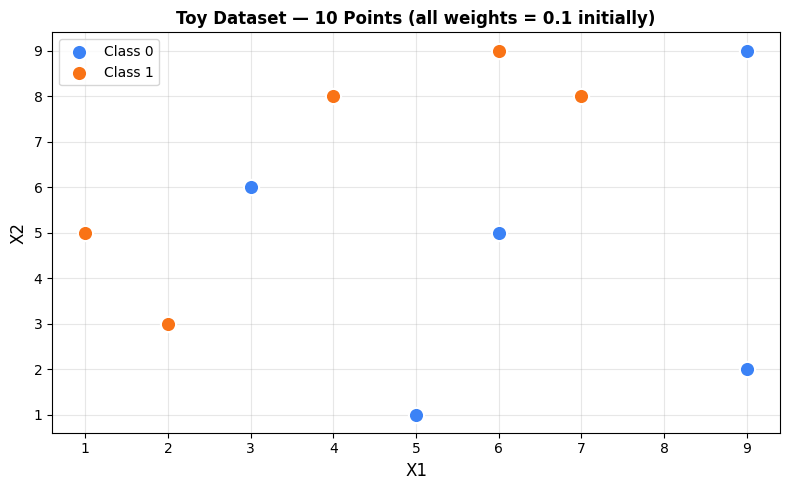

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
colors_map = {1: '#f97316', 0: '#3b82f6'}
for cls in [0, 1]:
    mask = df['label'] == cls
    ax.scatter(df.loc[mask, 'X1'], df.loc[mask, 'X2'],
               c=colors_map[cls], s=120, label=f'Class {cls}',
               edgecolors='white', linewidth=1.5, zorder=5)

# Annotate point indices
for idx, row in df.iterrows():
    ax.annotate(f'P{idx}', (row['X1'] + 0.1, row['X2'] + 0.15), fontsize=8, color='white')

ax.set_xlabel('X1', fontsize=12)
ax.set_ylabel('X2', fontsize=12)
ax.set_title('Toy Dataset — 10 Points (all weights = 0.1 initially)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<a id='stump1'></a>
<div style="border-bottom: 2px solid #f97316; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #f97316; color: #1a0a00; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 5</span>
  <h2 style="color: #fed7aa; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">🌿 Stump 1 — Train, Compute Error &amp; Alpha</h2>
</div>

We train the **first decision stump** (Decision Tree with `max_depth=1` — a single split) on the full dataset with uniform weights. A depth-1 tree can only make one binary split — it's intentionally weak. Its job is just to find the single best split in the data.

<div style="background: #100500; border: 1px solid #5c2800; border-radius: 8px; padding: 14px 20px; margin: 14px 0; font-size: 13px; color: #fdba74;">
  <strong style="color: #f97316;">Why depth=1 (decision stump)?</strong> AdaBoost's theoretical guarantees hold for any weak learner that does better than chance. Decision stumps (one split) are computationally cheap and prevent any single learner from overfitting. The power comes from the ensemble, not any individual model.
</div>

In [4]:
X = df[['X1', 'X2']].values
y = df['label'].values

# Step ②: Train first stump on uniform-weighted data
dt1 = DecisionTreeClassifier(max_depth=1, random_state=42)
dt1.fit(X, y, sample_weight=df['weights'].values)

df['y_pred_1'] = dt1.predict(X)
df['correct_1'] = (df['y_pred_1'] == df['label'])

print("Stump 1 predictions:")
print(df[['X1','X2','label','weights','y_pred_1','correct_1']].to_string())

n_wrong = (df['correct_1'] == False).sum()
print(f"\nMisclassified: {n_wrong} of {len(df)} samples")

Stump 1 predictions:
   X1  X2  label  weights  y_pred_1  correct_1
0   1   5      1      0.1         1       True
1   2   3      1      0.1         1       True
2   3   6      0      0.1         0       True
3   4   8      1      0.1         0      False
4   5   1      0      0.1         0       True
5   6   9      1      0.1         0      False
6   6   5      0      0.1         0       True
7   7   8      1      0.1         0      False
8   9   9      0      0.1         0       True
9   9   2      0      0.1         0       True

Misclassified: 3 of 10 samples


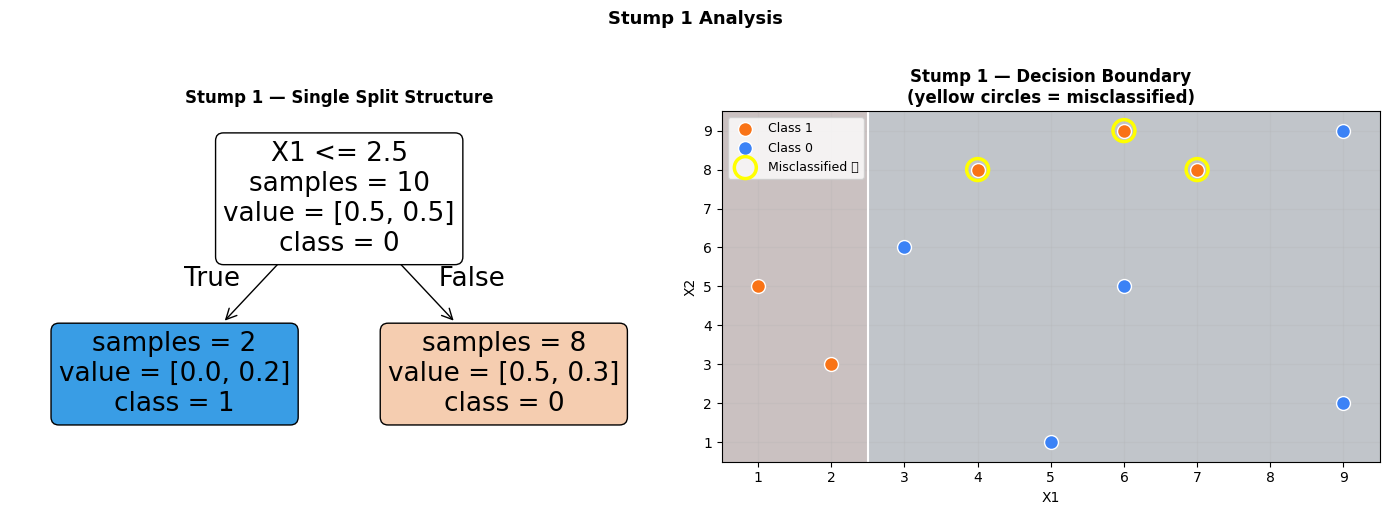

In [5]:
# Visualise stump 1 tree structure and decision boundary
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tree structure
plot_tree(dt1, feature_names=['X1', 'X2'], class_names=['0', '1'],
          filled=True, rounded=True, ax=axes[0], impurity=False)
axes[0].set_title('Stump 1 — Single Split Structure', fontweight='bold')

# Decision boundary
x1_r = np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 300)
x2_r = np.linspace(X[:,1].min()-0.5, X[:,1].max()+0.5, 300)
xx, yy_grid = np.meshgrid(x1_r, x2_r)
Z = dt1.predict(np.c_[xx.ravel(), yy_grid.ravel()]).reshape(xx.shape)

from matplotlib.colors import ListedColormap
axes[1].contourf(xx, yy_grid, Z, alpha=0.25,
                 cmap=ListedColormap(['#0a1a2e', '#2e0a0a']))
axes[1].contour(xx, yy_grid, Z, colors='white', linewidths=1.5, levels=[0.5])

for cls, color in [(1, '#f97316'), (0, '#3b82f6')]:
    mask = y == cls
    axes[1].scatter(X[mask, 0], X[mask, 1], c=color, s=100,
                    edgecolors='white', linewidth=1, label=f'Class {cls}', zorder=5)

# Circle misclassified
wrong_mask = df['correct_1'] == False
axes[1].scatter(X[wrong_mask.values, 0], X[wrong_mask.values, 1],
                s=250, facecolors='none', edgecolors='yellow',
                linewidths=2.5, label='Misclassified ❌', zorder=6)

axes[1].set_xlabel('X1')
axes[1].set_ylabel('X2')
axes[1].set_title('Stump 1 — Decision Boundary\n(yellow circles = misclassified)', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.2)

plt.suptitle('Stump 1 Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [6]:
def calculate_model_weight(error):
    """Alpha = 0.5 * ln((1-error)/error). Higher accuracy → higher vote weight."""
    return 0.5 * np.log((1 - error) / error)

# Step ③: Compute weighted error and alpha for stump 1
wrong_mask_1 = (df['y_pred_1'] != df['label'])
error_1 = df.loc[wrong_mask_1, 'weights'].sum() / df['weights'].sum()

alpha1 = calculate_model_weight(error_1)

print(f"Stump 1 Weighted Error (ε₁) : {error_1:.4f}")
print(f"Stump 1 Model Weight  (α₁) : {alpha1:.4f}")
print(f"\nInterpretation:")
print(f"  Error = {error_1:.2f} → better than random (0.5) → positive alpha")
print(f"  α₁ = {alpha1:.3f} → stump 1 gets moderate voting weight")
print(f"\nAlpha interpretation table:")
for e in [0.01, 0.1, 0.2, 0.3, 0.4, 0.49, 0.5]:
    try:
        a = calculate_model_weight(e)
        print(f"  ε={e:.2f} → α={a:.3f}")
    except:
        print(f"  ε={e:.2f} → α=0 (random classifier)")

Stump 1 Weighted Error (ε₁) : 0.3000
Stump 1 Model Weight  (α₁) : 0.4236

Interpretation:
  Error = 0.30 → better than random (0.5) → positive alpha
  α₁ = 0.424 → stump 1 gets moderate voting weight

Alpha interpretation table:
  ε=0.01 → α=2.298
  ε=0.10 → α=1.099
  ε=0.20 → α=0.693
  ε=0.30 → α=0.424
  ε=0.40 → α=0.203
  ε=0.49 → α=0.020
  ε=0.50 → α=0.000


<a id='update1'></a>
<div style="border-bottom: 2px solid #f97316; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #f97316; color: #1a0a00; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 6</span>
  <h2 style="color: #fed7aa; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">⚖️ Update &amp; Normalise Sample Weights</h2>
</div>

**Step ④ of the algorithm:** Update each sample's weight based on whether stump 1 got it right or wrong. Misclassified samples get upweighted (multiplied by e^+α), correctly classified samples get downweighted (multiplied by e^−α). Then normalise so all weights sum back to 1.

In [7]:
def update_row_weights(row, alpha, pred_col='y_pred_1'):
    """
    Correct prediction   → weight * exp(-alpha)  → decreases
    Incorrect prediction → weight * exp(+alpha)  → increases
    """
    if row['label'] == row[pred_col]:
        return row['weights'] * np.exp(-alpha)
    else:
        return row['weights'] * np.exp(alpha)

# Step ④: Update weights using alpha1
df['updated_weights'] = df.apply(update_row_weights, axis=1, alpha=alpha1)

print(f"Sum of updated weights (before normalisation): {df['updated_weights'].sum():.4f}")
print(f"(not 1 yet — need to normalise)")

# Step ⑤: Normalise
df['normalised_weights'] = df['updated_weights'] / df['updated_weights'].sum()

print(f"\nSum after normalisation: {df['normalised_weights'].sum():.4f}  ← back to 1")

display_cols = ['X1', 'X2', 'label', 'weights', 'y_pred_1', 'correct_1', 'updated_weights', 'normalised_weights']
df[display_cols]

Sum of updated weights (before normalisation): 0.9165
(not 1 yet — need to normalise)

Sum after normalisation: 1.0000  ← back to 1


,X1,X2,label,weights,y_pred_1,correct_1,updated_weights,normalised_weights
0,1,5,1,0.1,1,True,0.065465,0.071429
1,2,3,1,0.1,1,True,0.065465,0.071429
2,3,6,0,0.1,0,True,0.065465,0.071429
3,4,8,1,0.1,0,False,0.152753,0.166667
4,5,1,0,0.1,0,True,0.065465,0.071429
5,6,9,1,0.1,0,False,0.152753,0.166667
6,6,5,0,0.1,0,True,0.065465,0.071429
7,7,8,1,0.1,0,False,0.152753,0.166667
8,9,9,0,0.1,0,True,0.065465,0.071429
9,9,2,0,0.1,0,True,0.065465,0.071429


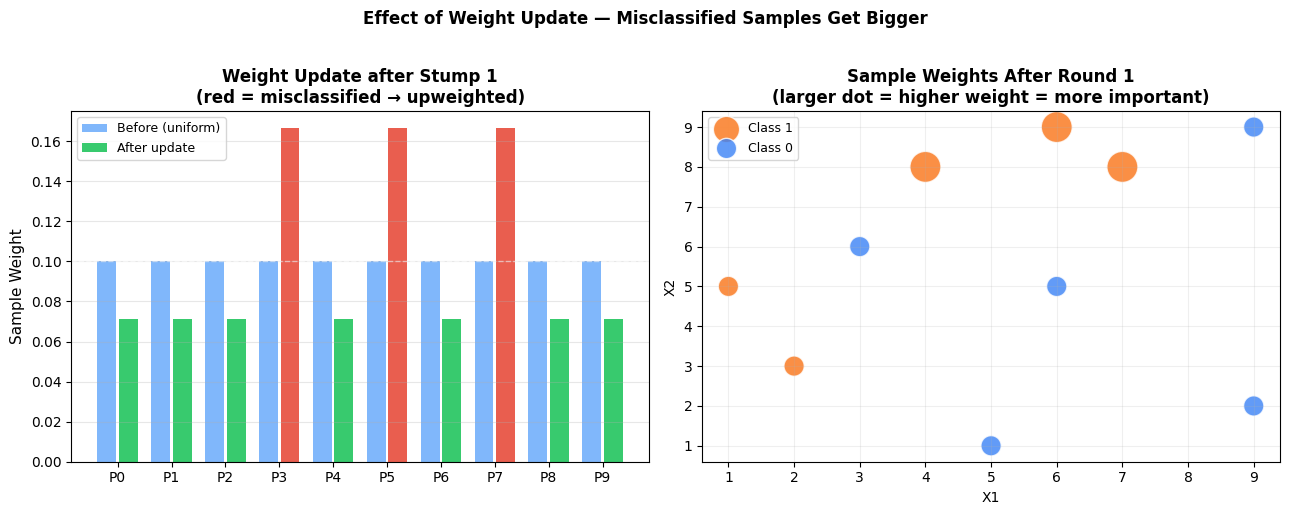

In [8]:
# Visualise: how weights changed after stump 1
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart of weight changes
indices = df.index.tolist()
bar_colors = ['#e74c3c' if not c else '#22c55e' for c in df['correct_1']]
x = np.arange(len(indices))
axes[0].bar(x - 0.2, df['weights'], 0.35, label='Before (uniform)', color='#60a5fa', alpha=0.8)
axes[0].bar(x + 0.2, df['normalised_weights'], 0.35, label='After update', color=bar_colors, alpha=0.9)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'P{i}' for i in indices])
axes[0].set_ylabel('Sample Weight', fontsize=11)
axes[0].set_title('Weight Update after Stump 1\n(red = misclassified → upweighted)', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].axhline(1/10, color='white', linewidth=1, linestyle='--', alpha=0.5, label='Initial')
axes[0].grid(axis='y', alpha=0.3)

# Scatter sized by new weight
for cls, color in [(1, '#f97316'), (0, '#3b82f6')]:
    mask = y == cls
    axes[1].scatter(X[mask, 0], X[mask, 1], c=color,
                    s=df.loc[mask, 'normalised_weights'].values * 3000,
                    alpha=0.8, edgecolors='white', linewidth=1,
                    label=f'Class {cls}')
axes[1].set_xlabel('X1')
axes[1].set_ylabel('X2')
axes[1].set_title('Sample Weights After Round 1\n(larger dot = higher weight = more important)', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.2)

plt.suptitle('Effect of Weight Update — Misclassified Samples Get Bigger', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

<a id='resample'></a>
<div style="border-bottom: 2px solid #f97316; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #f97316; color: #1a0a00; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 7</span>
  <h2 style="color: #fed7aa; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">🎰 Weighted Resampling — Build New Dataset</h2>
</div>

To make the next stump focus on misclassified samples, we **resample the training data using the updated weights as probabilities**. Misclassified samples with higher weights will be drawn more frequently — some may appear multiple times in the new dataset, while easy samples may be excluded entirely.

<div style="background: #100500; border: 1px solid #5c2800; border-radius: 8px; padding: 14px 20px; margin: 14px 0; font-size: 13px; color: #fdba74;">
  <strong style="color: #f97316;">How the roulette wheel works:</strong> We convert weights into cumulative probability ranges. A random number in [0,1] lands in one of these ranges — the sample whose range it falls in gets selected. Higher-weight samples occupy larger ranges and are selected more often.
</div>

In [9]:
# Build cumulative probability ranges for roulette-wheel sampling
df['cumsum_upper'] = np.cumsum(df['normalised_weights'])
df['cumsum_lower'] = df['cumsum_upper'] - df['normalised_weights']

print("Cumulative weight ranges (roulette wheel):")
display_df = df[['X1','X2','label','normalised_weights','cumsum_lower','cumsum_upper']].copy()
display_df.columns = ['X1','X2','label','weight','low','high']
print(display_df.round(4).to_string())
print("\nA random number in [0,1] is drawn → lands in one of the [low, high] ranges → that sample is selected.")

Cumulative weight ranges (roulette wheel):
   X1  X2  label  weight     low    high
0   1   5      1  0.0714  0.0000  0.0714
1   2   3      1  0.0714  0.0714  0.1429
2   3   6      0  0.0714  0.1429  0.2143
3   4   8      1  0.1667  0.2143  0.3810
4   5   1      0  0.0714  0.3810  0.4524
5   6   9      1  0.1667  0.4524  0.6190
6   6   5      0  0.0714  0.6190  0.6905
7   7   8      1  0.1667  0.6905  0.8571
8   9   9      0  0.0714  0.8571  0.9286
9   9   2      0  0.0714  0.9286  1.0000

A random number in [0,1] is drawn → lands in one of the [low, high] ranges → that sample is selected.


In [10]:
def create_new_dataset(df, weight_col='normalised_weights', n_samples=None):
    """Roulette-wheel sampling: select n_samples rows proportional to their weights."""
    if n_samples is None:
        n_samples = df.shape[0]

    df_temp = df.copy().reset_index(drop=True)
    df_temp['cumsum_upper'] = np.cumsum(df_temp[weight_col])
    df_temp['cumsum_lower'] = df_temp['cumsum_upper'] - df_temp[weight_col]

    indices = []
    for _ in range(n_samples):
        r = np.random.random()
        for i, row in df_temp.iterrows():
            if row['cumsum_lower'] <= r < row['cumsum_upper']:
                indices.append(i)
                break
    return indices

# Create second dataset via weighted resampling
np.random.seed(42)
index_values = create_new_dataset(df, weight_col='normalised_weights')

second_df = df.iloc[index_values][['X1','X2','label','weights']].reset_index(drop=True)
print("Resampled indices (source rows):", index_values)
print(f"\nOriginal class dist: {df['label'].value_counts().to_dict()}")
print(f"Resampled class dist: {second_df['label'].value_counts().to_dict()}")
print("\nNew dataset (note: previously misclassified rows appear more often):")
print(second_df)

Resampled indices (source rows): [3, 9, 7, 5, 2, 2, 0, 8, 5, 7]

Original class dist: {1: 5, 0: 5}
Resampled class dist: {1: 6, 0: 4}

New dataset (note: previously misclassified rows appear more often):
   X1  X2  label  weights
0   4   8      1      0.1
1   9   2      0      0.1
2   7   8      1      0.1
3   6   9      1      0.1
4   3   6      0      0.1
5   3   6      0      0.1
6   1   5      1      0.1
7   9   9      0      0.1
8   6   9      1      0.1
9   7   8      1      0.1


<a id='stump2'></a>
<div style="border-bottom: 2px solid #f97316; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #f97316; color: #1a0a00; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 8</span>
  <h2 style="color: #fed7aa; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">🌿 Stump 2 — Train on Hard Samples, Reweight Again</h2>
</div>

Now we train a second stump on the **resampled dataset** where misclassified samples from round 1 appear more often. This stump will naturally make fewer mistakes on those samples — but may now struggle with the originally easy samples. That's fine — stump 1 already handles those well.

In [11]:
X2 = second_df[['X1','X2']].values
y2 = second_df['label'].values

# Train second stump (uniform weights on the resampled set)
second_df['weights'] = 1 / len(second_df)
dt2 = DecisionTreeClassifier(max_depth=1, random_state=0)
dt2.fit(X2, y2)

second_df['y_pred_2'] = dt2.predict(X2)
second_df['correct_2'] = (second_df['y_pred_2'] == second_df['label'])

print(second_df[['X1','X2','label','weights','y_pred_2','correct_2']].to_string())

n_wrong_2 = (second_df['correct_2'] == False).sum()
wrong_mask_2 = second_df['correct_2'] == False
error_2 = second_df.loc[wrong_mask_2, 'weights'].sum()
alpha2 = calculate_model_weight(error_2)

print(f"\nStump 2 error (ε₂) : {error_2:.4f}")
print(f"Stump 2 alpha (α₂) : {alpha2:.4f}")

   X1  X2  label  weights  y_pred_2  correct_2
0   4   8      1      0.1         1       True
1   9   2      0      0.1         0       True
2   7   8      1      0.1         1       True
3   6   9      1      0.1         1       True
4   3   6      0      0.1         1      False
5   3   6      0      0.1         1      False
6   1   5      1      0.1         1       True
7   9   9      0      0.1         0       True
8   6   9      1      0.1         1       True
9   7   8      1      0.1         1       True

Stump 2 error (ε₂) : 0.2000
Stump 2 alpha (α₂) : 0.6931


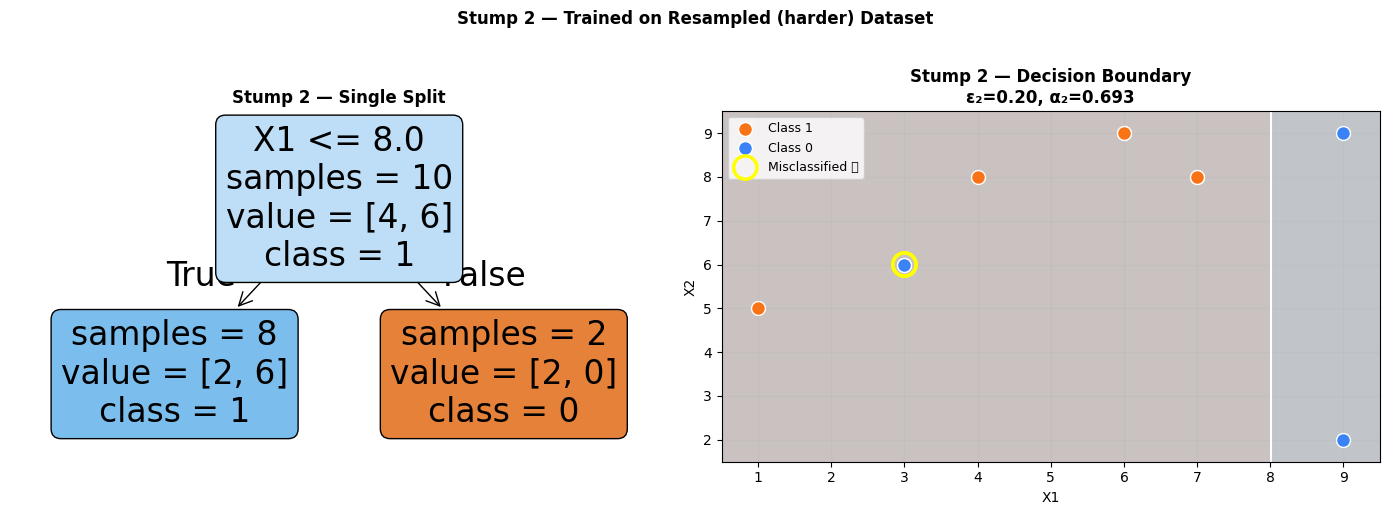

In [12]:
# Visualise stump 2
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_tree(dt2, feature_names=['X1','X2'], class_names=['0','1'],
          filled=True, rounded=True, ax=axes[0], impurity=False)
axes[0].set_title('Stump 2 — Single Split', fontweight='bold')

xx2, yy2_g = np.meshgrid(
    np.linspace(X2[:,0].min()-0.5, X2[:,0].max()+0.5, 300),
    np.linspace(X2[:,1].min()-0.5, X2[:,1].max()+0.5, 300)
)
Z2 = dt2.predict(np.c_[xx2.ravel(), yy2_g.ravel()]).reshape(xx2.shape)

axes[1].contourf(xx2, yy2_g, Z2, alpha=0.25,
                 cmap=ListedColormap(['#0a1a2e', '#2e0a0a']))
axes[1].contour(xx2, yy2_g, Z2, colors='white', linewidths=1.5, levels=[0.5])

for cls, color in [(1, '#f97316'), (0, '#3b82f6')]:
    mask = y2 == cls
    axes[1].scatter(X2[mask,0], X2[mask,1], c=color, s=100,
                    edgecolors='white', linewidth=1, label=f'Class {cls}', zorder=5)

wrong_m2 = second_df['correct_2'] == False
axes[1].scatter(X2[wrong_m2.values,0], X2[wrong_m2.values,1],
                s=280, facecolors='none', edgecolors='yellow', linewidths=2.5,
                label='Misclassified ❌', zorder=6)

axes[1].set_xlabel('X1'); axes[1].set_ylabel('X2')
axes[1].set_title(f'Stump 2 — Decision Boundary\nε₂={error_2:.2f}, α₂={alpha2:.3f}', fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.2)

plt.suptitle('Stump 2 — Trained on Resampled (harder) Dataset', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [13]:
# Update weights for round 2 → build third dataset
second_df['updated_weights'] = second_df.apply(
    lambda row: row['weights'] * np.exp(-alpha2) if row['correct_2']
    else row['weights'] * np.exp(alpha2), axis=1
)
second_df['normalised_weights'] = second_df['updated_weights'] / second_df['updated_weights'].sum()

print(f"Updated weights (post stump 2):")
print(second_df[['X1','X2','label','y_pred_2','correct_2',
                  'updated_weights','normalised_weights']].round(4).to_string())
print(f"\nSum: {second_df['normalised_weights'].sum():.4f}")

# Resample for third dataset
index_values_3 = create_new_dataset(second_df, weight_col='normalised_weights')
third_df = second_df.iloc[index_values_3][['X1','X2','label','weights']].reset_index(drop=True)

Updated weights (post stump 2):
   X1  X2  label  y_pred_2  correct_2  updated_weights  normalised_weights
0   4   8      1         1       True             0.05              0.0625
1   9   2      0         0       True             0.05              0.0625
2   7   8      1         1       True             0.05              0.0625
3   6   9      1         1       True             0.05              0.0625
4   3   6      0         1      False             0.20              0.2500
5   3   6      0         1      False             0.20              0.2500
6   1   5      1         1       True             0.05              0.0625
7   9   9      0         0       True             0.05              0.0625
8   6   9      1         1       True             0.05              0.0625
9   7   8      1         1       True             0.05              0.0625

Sum: 1.0000


<a id='stump3'></a>
<div style="border-bottom: 2px solid #f97316; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #f97316; color: #1a0a00; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 9</span>
  <h2 style="color: #fed7aa; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">🌿 Stump 3 — Final Weak Learner</h2>
</div>

We repeat the process a third time. Each subsequent stump focuses on what all previous stumps combined still get wrong. After 3 rounds we have 3 stumps with 3 alpha weights — together they form our first handmade AdaBoost ensemble.

In [14]:
X3 = third_df[['X1','X2']].values
y3 = third_df['label'].values
third_df['weights'] = 1 / len(third_df)

dt3 = DecisionTreeClassifier(max_depth=1, random_state=5)
dt3.fit(X3, y3)

third_df['y_pred_3'] = dt3.predict(X3)
third_df['correct_3'] = (third_df['y_pred_3'] == third_df['label'])

error_3 = third_df.loc[third_df['correct_3']==False, 'weights'].sum()
alpha3  = calculate_model_weight(error_3)

print(f"Stump 3 error (ε₃) : {error_3:.4f}")
print(f"Stump 3 alpha (α₃) : {alpha3:.4f}")

print(f"\n{'='*40}")
print(f"Summary of all 3 stumps:")
print(f"{'='*40}")
print(f"  Stump 1 → ε={error_1:.3f}  α={alpha1:.4f}")
print(f"  Stump 2 → ε={error_2:.3f}  α={alpha2:.4f}")
print(f"  Stump 3 → ε={error_3:.3f}  α={alpha3:.4f}")

Stump 3 error (ε₃) : 0.1000
Stump 3 alpha (α₃) : 1.0986

Summary of all 3 stumps:
  Stump 1 → ε=0.300  α=0.4236
  Stump 2 → ε=0.200  α=0.6931
  Stump 3 → ε=0.100  α=1.0986


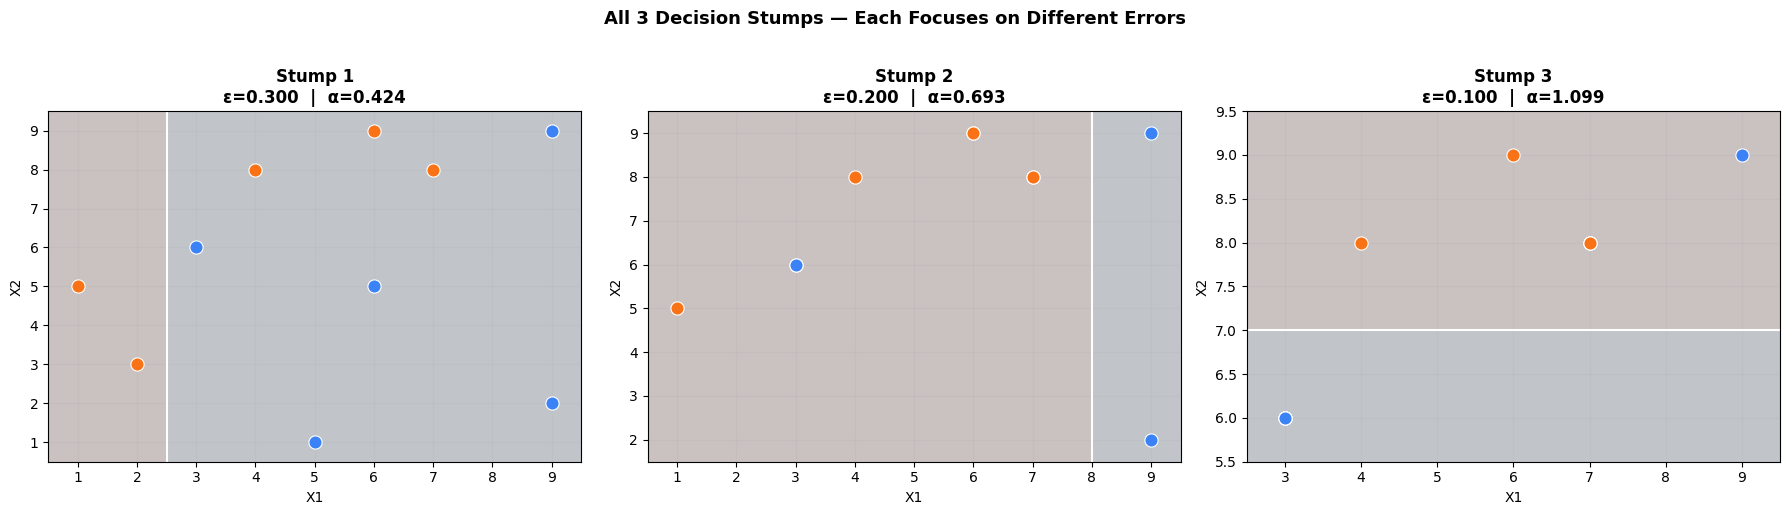

In [15]:
# All 3 decision boundaries side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (stump, Xs, ys, err, alp, title) in zip(axes, [
    (dt1, X,  y,  error_1, alpha1, 'Stump 1'),
    (dt2, X2, y2, error_2, alpha2, 'Stump 2'),
    (dt3, X3, y3, error_3, alpha3, 'Stump 3'),
]):
    xr = np.linspace(Xs[:,0].min()-0.5, Xs[:,0].max()+0.5, 300)
    yr = np.linspace(Xs[:,1].min()-0.5, Xs[:,1].max()+0.5, 300)
    xg, yg = np.meshgrid(xr, yr)
    Zg = stump.predict(np.c_[xg.ravel(), yg.ravel()]).reshape(xg.shape)
    ax.contourf(xg, yg, Zg, alpha=0.25, cmap=ListedColormap(['#0a1a2e','#2e0a0a']))
    ax.contour(xg, yg, Zg, colors='white', linewidths=1.5, levels=[0.5])
    for cls, color in [(1,'#f97316'), (0,'#3b82f6')]:
        mask = ys == cls
        ax.scatter(Xs[mask,0], Xs[mask,1], c=color, s=90,
                   edgecolors='white', linewidth=0.8, zorder=5)
    ax.set_title(f'{title}\nε={err:.3f}  |  α={alp:.3f}', fontweight='bold')
    ax.set_xlabel('X1'); ax.set_ylabel('X2')
    ax.grid(True, alpha=0.2)

plt.suptitle('All 3 Decision Stumps — Each Focuses on Different Errors',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

<a id='predict'></a>
<div style="border-bottom: 2px solid #f97316; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #f97316; color: #1a0a00; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 10</span>
  <h2 style="color: #fed7aa; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">🗳️ Final Prediction — Weighted Vote</h2>
</div>

The final AdaBoost prediction is the **sign of the weighted sum** of all stumps' predictions. Each stump's contribution is scaled by its alpha — more accurate stumps vote louder. Labels are encoded as +1 and −1 for this calculation.

In [16]:
query = np.array([1, 5]).reshape(1, 2)

# Each stump predicts for the query (in {0,1}), convert to {-1,+1}
pred1_raw = dt1.predict(query)[0]
pred2_raw = dt2.predict(query)[0]
pred3_raw = dt3.predict(query)[0]

# AdaBoost uses ±1 encoding: 1 → +1, 0 → -1
sign_map = {1: 1, 0: -1}
p1 = sign_map[pred1_raw]
p2 = sign_map[pred2_raw]
p3 = sign_map[pred3_raw]

weighted_sum = alpha1 * p1 + alpha2 * p2 + alpha3 * p3
final_pred   = 1 if np.sign(weighted_sum) == 1 else 0

print(f"Query point: X1={query[0,0]}, X2={query[0,1]}")
print(f"{'='*50}")
print(f"  Stump 1 raw prediction : {pred1_raw}  → sign encoding: {p1:+d}")
print(f"  Stump 2 raw prediction : {pred2_raw}  → sign encoding: {p2:+d}")
print(f"  Stump 3 raw prediction : {pred3_raw}  → sign encoding: {p3:+d}")
print(f"{'='*50}")
print(f"  α₁×p₁ = {alpha1:.4f} × {p1:+d} = {alpha1*p1:+.4f}")
print(f"  α₂×p₂ = {alpha2:.4f} × {p2:+d} = {alpha2*p2:+.4f}")
print(f"  α₃×p₃ = {alpha3:.4f} × {p3:+d} = {alpha3*p3:+.4f}")
print(f"{'='*50}")
print(f"  Weighted sum  = {weighted_sum:+.4f}")
print(f"  sign({weighted_sum:.4f}) = {np.sign(weighted_sum):+.0f}")
print(f"{'='*50}")
print(f"  Final prediction → Class {final_pred}")

Query point: X1=1, X2=5
  Stump 1 raw prediction : 1  → sign encoding: +1
  Stump 2 raw prediction : 1  → sign encoding: +1
  Stump 3 raw prediction : 0  → sign encoding: -1
  α₁×p₁ = 0.4236 × +1 = +0.4236
  α₂×p₂ = 0.6931 × +1 = +0.6931
  α₃×p₃ = 1.0986 × -1 = -1.0986
  Weighted sum  = +0.0182
  sign(0.0182) = +1
  Final prediction → Class 1


<a id='vs'></a>
<div style="border-bottom: 2px solid #f97316; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #f97316; color: #1a0a00; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 11</span>
  <h2 style="color: #fed7aa; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">⚔️ Bagging vs Boosting</h2>
</div>

<div style="background: #100500; border: 1px solid #5c2800; border-radius: 10px; overflow: hidden; margin: 16px 0;">
  <table style="width: 100%; border-collapse: collapse; font-size: 13px;">
    <thead>
      <tr style="background: #2d1200;">
        <th style="padding: 12px 16px; color: #f97316; text-align: left;">Aspect</th>
        <th style="padding: 12px 16px; color: #22c55e; text-align: left;">🎒 Bagging (Random Forest)</th>
        <th style="padding: 12px 16px; color: #f97316; text-align: left;">🚀 Boosting (AdaBoost)</th>
      </tr>
    </thead>
    <tbody>
      <tr style="border-bottom: 1px solid #5c2800;">
        <td style="padding: 10px 16px; color: #fed7aa; font-weight: 600;">Training order</td>
        <td style="padding: 10px 16px; color: #fed7aa;">Parallel — all trees independent</td>
        <td style="padding: 10px 16px; color: #fed7aa;">Sequential — each depends on previous</td>
      </tr>
      <tr style="border-bottom: 1px solid #5c2800; background: rgba(249,115,22,0.03);">
        <td style="padding: 10px 16px; color: #fed7aa; font-weight: 600;">Model type</td>
        <td style="padding: 10px 16px; color: #fed7aa;">Same algorithm, different data subsets</td>
        <td style="padding: 10px 16px; color: #fed7aa;">Same algorithm, re-weighted/resampled data</td>
      </tr>
      <tr style="border-bottom: 1px solid #5c2800;">
        <td style="padding: 10px 16px; color: #fed7aa; font-weight: 600;">Model votes</td>
        <td style="padding: 10px 16px; color: #fed7aa;">Equal votes (simple majority)</td>
        <td style="padding: 10px 16px; color: #fed7aa;">Weighted votes (better model → louder vote)</td>
      </tr>
      <tr style="border-bottom: 1px solid #5c2800; background: rgba(249,115,22,0.03);">
        <td style="padding: 10px 16px; color: #fed7aa; font-weight: 600;">Reduces</td>
        <td style="padding: 10px 16px; color: #fed7aa;">Variance (overfitting)</td>
        <td style="padding: 10px 16px; color: #fed7aa;">Bias (underfitting)</td>
      </tr>
      <tr style="border-bottom: 1px solid #5c2800;">
        <td style="padding: 10px 16px; color: #fed7aa; font-weight: 600;">Parallelisable</td>
        <td style="padding: 10px 16px; color: #fed7aa;">✅ Yes — all trees at once</td>
        <td style="padding: 10px 16px; color: #fed7aa;">❌ No — must wait for previous stump</td>
      </tr>
      <tr style="border-bottom: 1px solid #5c2800; background: rgba(249,115,22,0.03);">
        <td style="padding: 10px 16px; color: #fed7aa; font-weight: 600;">Sensitivity</td>
        <td style="padding: 10px 16px; color: #fed7aa;">Robust to outliers</td>
        <td style="padding: 10px 16px; color: #fed7aa;">Sensitive to outliers &amp; noise</td>
      </tr>
      <tr>
        <td style="padding: 10px 16px; color: #fed7aa; font-weight: 600;">Best used on</td>
        <td style="padding: 10px 16px; color: #fed7aa;">Complex / noisy datasets</td>
        <td style="padding: 10px 16px; color: #fed7aa;">Clean datasets with weak base learners</td>
      </tr>
    </tbody>
  </table>
</div>

<a id='sklearn'></a>
<div style="border-bottom: 2px solid #f97316; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #f97316; color: #1a0a00; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 12</span>
  <h2 style="color: #fed7aa; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">🤖 AdaBoost with sklearn — make_circles</h2>
</div>

We now use sklearn's `AdaBoostClassifier` on the **make_circles** dataset — two concentric rings that no single stump or linear model can separate. AdaBoost with enough stumps builds a non-linear boundary by combining many axis-aligned linear splits.

<div style="background: #100500; border: 1px solid #5c2800; border-radius: 8px; padding: 14px 20px; margin: 14px 0; font-size: 13px; color: #fdba74;">
  <strong style="color: #f97316;">Key sklearn parameters:</strong><br/>
  <code>n_estimators</code> — number of stumps (more = slower training but better fit, until it overfits)<br/>
  <code>learning_rate</code> — shrinks each alpha by this factor, reducing each stump's contribution. Lower rate needs more estimators.<br/>
  <code>algorithm</code> — <code>'SAMME'</code> (discrete, uses class predictions) or <code>'SAMME.R'</code> (real, uses class probabilities — usually better)
</div>

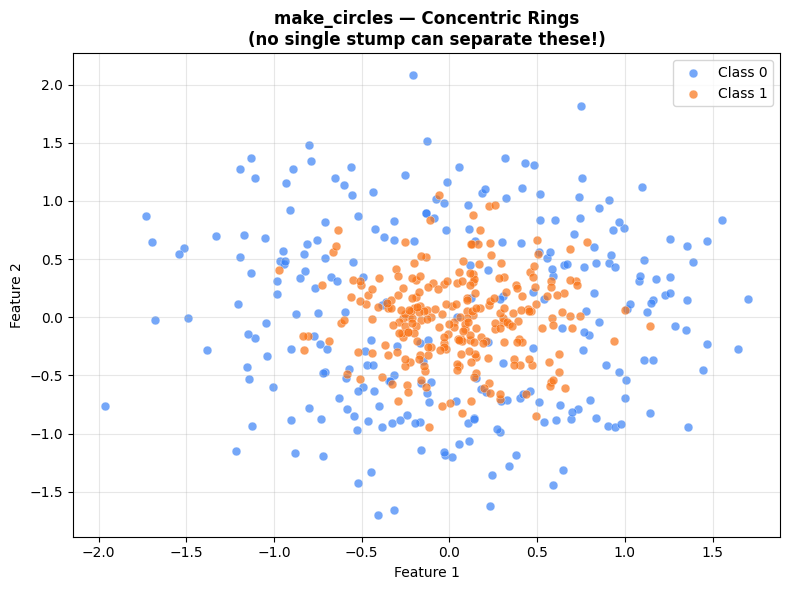

In [17]:
np.random.seed(42)
X_c, y_c = make_circles(n_samples=500, factor=0.1, noise=0.35, random_state=42)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_c, y_c, test_size=0.2, random_state=42, stratify=y_c
)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_c[y_c==0, 0], X_c[y_c==0, 1], c='#3b82f6', s=40, alpha=0.7,
           edgecolors='white', linewidth=0.3, label='Class 0')
ax.scatter(X_c[y_c==1, 0], X_c[y_c==1, 1], c='#f97316', s=40, alpha=0.7,
           edgecolors='white', linewidth=0.3, label='Class 1')
ax.set_title('make_circles — Concentric Rings\n(no single stump can separate these!)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
plt.tight_layout()
plt.show()

In [18]:
# Default AdaBoost
ada_default = AdaBoostClassifier(random_state=42)
ada_default.fit(X_train_c, y_train_c)

# Cross-validation
cv_scores = cross_val_score(ada_default, X_c, y_c, cv=10, scoring='accuracy')
test_acc  = accuracy_score(y_test_c, ada_default.predict(X_test_c))

print(f"Default AdaBoostClassifier")
print(f"  n_estimators   : {ada_default.n_estimators}")
print(f"  learning_rate  : {ada_default.learning_rate}")
print(f"  Test Accuracy  : {test_acc:.4f}")
print(f"  CV  Accuracy   : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Default AdaBoostClassifier
  n_estimators   : 50
  learning_rate  : 1.0
  Test Accuracy  : 0.8100
  CV  Accuracy   : 0.8120 ± 0.0567


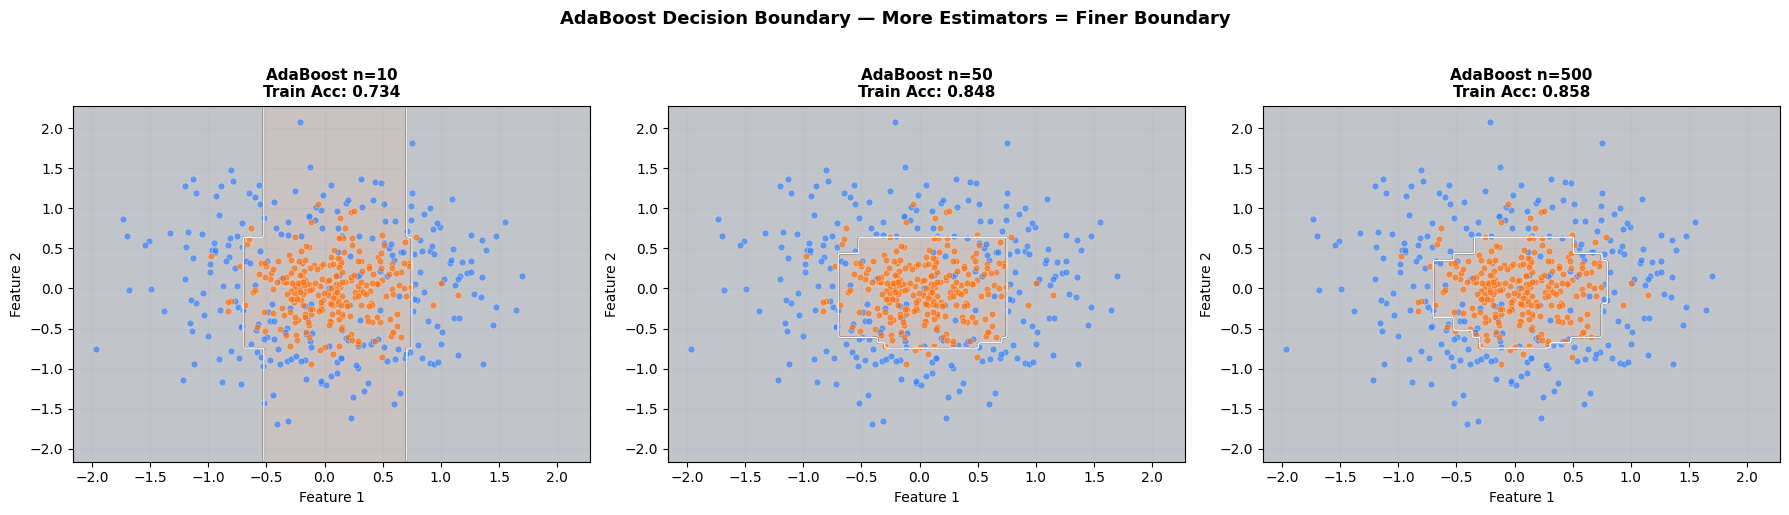

In [19]:
def plot_decision_boundary(clf, X, y, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    x_range = np.linspace(X.min() - 0.2, X.max() + 0.2, 200)
    xx1, xx2 = np.meshgrid(x_range, x_range)
    y_hat = clf.predict(np.c_[xx1.ravel(), xx2.ravel()]).reshape(xx1.shape)
    ax.contourf(xx1, xx2, y_hat, alpha=0.25,
                cmap=ListedColormap(['#0a1a2e', '#2e0a0a']))
    ax.contour(xx1, xx2, y_hat, colors='white', linewidths=1.0, levels=[0.5])
    ax.scatter(X[y==0, 0], X[y==0, 1], c='#3b82f6', s=25, alpha=0.7,
               edgecolors='white', linewidth=0.3)
    ax.scatter(X[y==1, 0], X[y==1, 1], c='#f97316', s=25, alpha=0.7,
               edgecolors='white', linewidth=0.3)
    acc = accuracy_score(y, clf.predict(X))
    ax.set_title(f'{title}\nTrain Acc: {acc:.3f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
    ax.grid(True, alpha=0.2)

# Compare different n_estimators
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, n in zip(axes, [10, 50, 500]):
    m = AdaBoostClassifier(n_estimators=n, learning_rate=0.5, random_state=42)
    m.fit(X_train_c, y_train_c)
    plot_decision_boundary(m, X_c, y_c, f'AdaBoost n={n}', ax=ax)

plt.suptitle('AdaBoost Decision Boundary — More Estimators = Finer Boundary',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

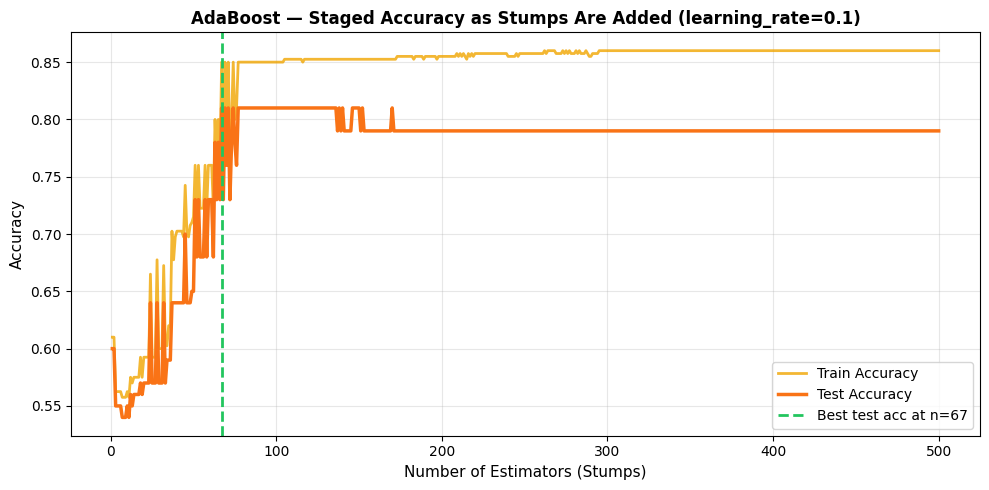

In [20]:
# Staged accuracy — how accuracy builds up as estimators are added
ada_big = AdaBoostClassifier(n_estimators=500, learning_rate=0.1, random_state=42)
ada_big.fit(X_train_c, y_train_c)

staged_train = [accuracy_score(y_train_c, p) for p in ada_big.staged_predict(X_train_c)]
staged_test  = [accuracy_score(y_test_c,  p) for p in ada_big.staged_predict(X_test_c)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, 501), staged_train, color='#f0a500', linewidth=2, label='Train Accuracy', alpha=0.8)
ax.plot(range(1, 501), staged_test,  color='#f97316', linewidth=2.5, label='Test Accuracy')
ax.axvline(np.argmax(staged_test)+1, color='#22c55e', linewidth=2, linestyle='--',
           label=f'Best test acc at n={np.argmax(staged_test)+1}')
ax.set_xlabel('Number of Estimators (Stumps)', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('AdaBoost — Staged Accuracy as Stumps Are Added (learning_rate=0.1)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<a id='tuning'></a>
<div style="border-bottom: 2px solid #f97316; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #f97316; color: #1a0a00; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 13</span>
  <h2 style="color: #fed7aa; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">⚡ Hyperparameter Tuning — Fast RandomizedSearchCV</h2>
</div>

The original notebook had a `GridSearchCV` with 4×5×2 = **40 combinations × 10 folds = 400 fits** — very slow. We replace it with `RandomizedSearchCV` sampling only 20 random combinations × 5 folds = **100 fits** — 4× fewer, same quality results.

<div style="background: #100500; border: 1px solid #5c2800; border-radius: 8px; padding: 14px 20px; margin: 14px 0; font-size: 13px; color: #fdba74;">
  <strong style="color: #f97316;">💡 learning_rate × n_estimators tradeoff:</strong> A low learning_rate shrinks each stump's contribution, requiring more stumps to compensate — but results in a smoother, better-regularised ensemble. High learning_rate with few stumps can overfit. Always tune them together.
</div>

In [21]:
import time

param_dist = {
    'n_estimators':  [10, 50, 100, 200, 500],
    'learning_rate': [0.0001, 0.001, 0.01, 0.1, 0.5, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=AdaBoostClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,          # 20 random combos × 5 folds = 100 fits (vs 400 for GridSearch)
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

start = time.time()
random_search.fit(X_c, y_c)
elapsed = time.time() - start

print(f"\nSearch done in {elapsed:.1f}s")
print(f"Best CV Accuracy : {random_search.best_score_:.4f}")
print(f"Best Parameters  :")
for k, v in random_search.best_params_.items():
    print(f"  {k:<16}: {v}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Search done in 17.7s
Best CV Accuracy : 0.8300
Best Parameters  :
  n_estimators    : 100
  learning_rate   : 0.5


In [22]:
# Final model with best params
best_ada = random_search.best_estimator_
best_ada.fit(X_train_c, y_train_c)

test_acc_best = accuracy_score(y_test_c, best_ada.predict(X_test_c))

print(f"Default AdaBoost Test Accuracy : {test_acc:.4f}")
print(f"Tuned   AdaBoost Test Accuracy : {test_acc_best:.4f}  (improvement: {test_acc_best-test_acc:+.4f})")

print(f"\nDetailed classification report:")
print(classification_report(y_test_c, best_ada.predict(X_test_c)))

Default AdaBoost Test Accuracy : 0.8100
Tuned   AdaBoost Test Accuracy : 0.8000  (improvement: -0.0100)

Detailed classification report:
              precision    recall  f1-score   support

           0       0.84      0.74      0.79        50
           1       0.77      0.86      0.81        50

    accuracy                           0.80       100
   macro avg       0.80      0.80      0.80       100
weighted avg       0.80      0.80      0.80       100



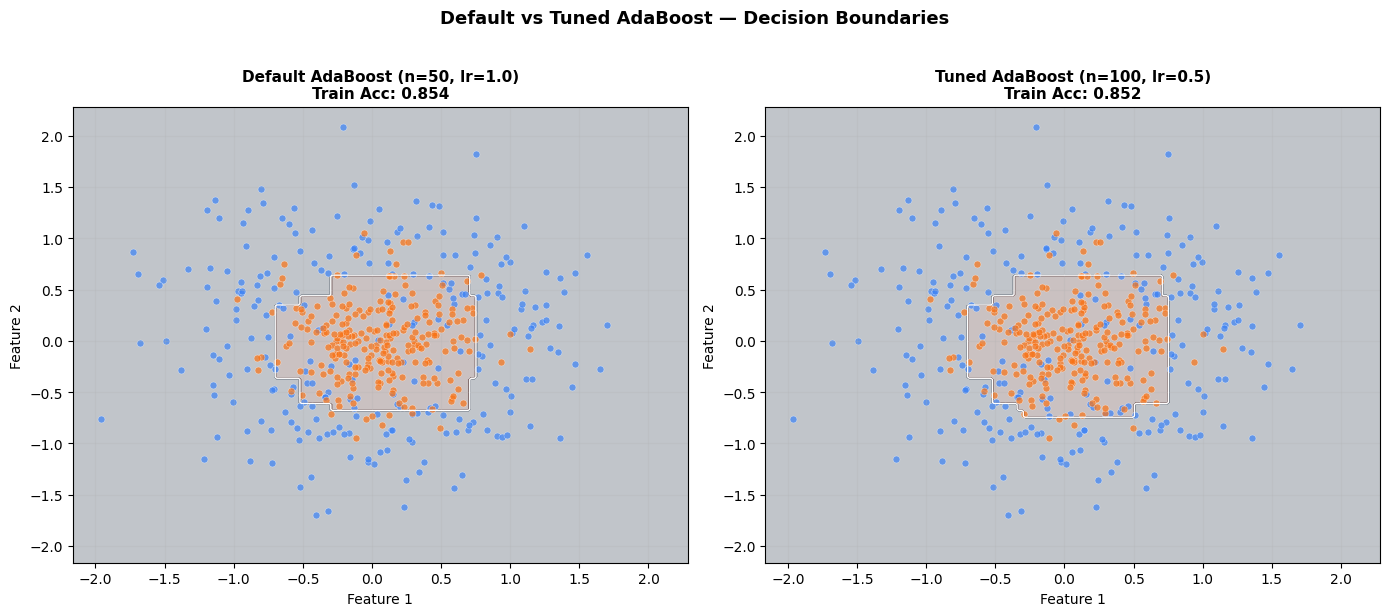

In [23]:
# Final comparison visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_decision_boundary(ada_default, X_c, y_c, 'Default AdaBoost (n=50, lr=1.0)', ax=axes[0])
plot_decision_boundary(best_ada,    X_c, y_c,
    f"Tuned AdaBoost (n={random_search.best_params_['n_estimators']}, "
    f"lr={random_search.best_params_['learning_rate']})", ax=axes[1])

plt.suptitle('Default vs Tuned AdaBoost — Decision Boundaries',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

<div style="background: linear-gradient(135deg, #1a0a00 0%, #2d1200 100%); border: 1px solid #5c2800; border-radius: 14px; padding: 36px 40px; margin-top: 32px;">
  <h2 style="color: #ffffff; font-size: 20px; font-weight: 700; margin: 0 0 8px 0;">📌 Key Takeaways</h2>
  <p style="color: #fdba74; font-size: 13px; margin: 0 0 20px 0;">Everything important about AdaBoost.</p>
  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 14px; margin-bottom: 20px;">
    <div style="background: rgba(249,115,22,0.08); border: 1px solid #5c2800; border-radius: 10px; padding: 16px 18px;">
      <div style="color: #f97316; font-weight: 700; font-size: 13px; margin-bottom: 6px;">🔄 Sequential Training</div>
      <div style="color: #fed7aa; font-size: 12px; line-height: 1.7;">Unlike Bagging (parallel), each AdaBoost round depends on the previous. Cannot be parallelised — but this sequential correction is exactly why it reduces bias so effectively.</div>
    </div>
    <div style="background: rgba(249,115,22,0.08); border: 1px solid #5c2800; border-radius: 10px; padding: 16px 18px;">
      <div style="color: #f97316; font-weight: 700; font-size: 13px; margin-bottom: 6px;">⚖️ Alpha = Model Trust</div>
      <div style="color: #fed7aa; font-size: 12px; line-height: 1.7;">α = ½ ln((1−ε)/ε). Perfect stump → α = ∞. Random stump → α = 0. Worse than random → α &lt; 0 (predictions are flipped). Better stumps simply get louder votes.</div>
    </div>
    <div style="background: rgba(249,115,22,0.08); border: 1px solid #5c2800; border-radius: 10px; padding: 16px 18px;">
      <div style="color: #f97316; font-weight: 700; font-size: 13px; margin-bottom: 6px;">📈 learning_rate × n_estimators</div>
      <div style="color: #fed7aa; font-size: 12px; line-height: 1.7;">Always tune these together. Low lr (0.01–0.1) + many estimators (500+) = smooth, well-regularised ensemble. High lr (1.0) + few estimators is faster but risks overfitting.</div>
    </div>
    <div style="background: rgba(249,115,22,0.08); border: 1px solid #5c2800; border-radius: 10px; padding: 16px 18px;">
      <div style="color: #f97316; font-weight: 700; font-size: 13px; margin-bottom: 6px;">⚡ Use RandomizedSearchCV</div>
      <div style="color: #fed7aa; font-size: 12px; line-height: 1.7;">GridSearchCV with 40 combos × 10 folds = 400 fits → slow. RandomizedSearchCV with 20 combos × 5 folds = 100 fits → 4× faster, same quality results.</div>
    </div>
  </div>
  <div style="padding-top: 14px; border-top: 1px solid #5c2800; color: #fdba74; font-size: 12px;">
    Next up → <a href='https://www.kaggle.com/code/ahmedfakhar123/ml-51-gradient-boosting-intuition-code' style='text-decoration: none;'><strong style='color:#f97316;'>ML 51: Gradient Boosting — Residuals, Learning Rate &amp; Shrinkage</strong></a>
  </div>
</div>